In [16]:
import math
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import scipy.sparse as sp

from reaction_diffusion.routines.tomo_fusion.tools import plotting_fcts as tomo_plots

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

from helpers import *

device: cuda


In [17]:
samples_idxs = np.arange(0, 100)
test_samples_path = Path("/home/fusiontomo/Repos/diffusion_tomography/test_set_sxr_samples/sxr_samples_with_background_coarse.npy")
test_samples = np.load(test_samples_path)[samples_idxs]


psis_path = Path("/home/fusiontomo/Repos/diffusion_tomography/test_set_sxr_samples/psis_coarse.npy")
psis = np.load(psis_path)[samples_idxs]

In [18]:
test_samples.shape

(100, 120, 40)

<Figure size 300x300 with 0 Axes>

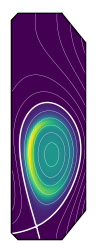

<Figure size 300x300 with 0 Axes>

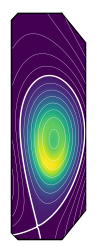

<Figure size 300x300 with 0 Axes>

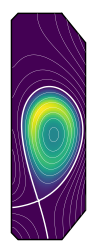

<Figure size 300x300 with 0 Axes>

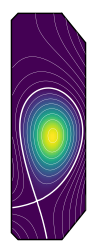

<Figure size 300x300 with 0 Axes>

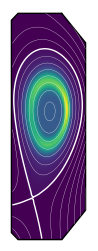

<Figure size 300x300 with 0 Axes>

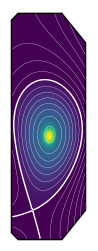

<Figure size 300x300 with 0 Axes>

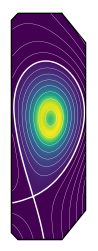

In [19]:
#save each individual eps figure
indices = np.array([0,1,12, 16, 22, 25, 55])
for i, idx in enumerate(indices):
    plt.figure(figsize=(3,3))
    tomo_plots.plot_profile(test_samples[idx], tcv_plot_clip=True,
                                contour_image=psis[idx], cmap="viridis", ax=None,
                                colorbar=False, contour_color="w",
                                aspect=None, lcfs_width=1, lwidth=0.2)
    # plt.title(f"Sample {idx}", fontsize=10)
    plt.axis('off')
    plt.savefig(f'figs/test_sample_{i}.eps', format='eps', bbox_inches="tight")